Text(0.5, 0, 'Frequency (Hz)')

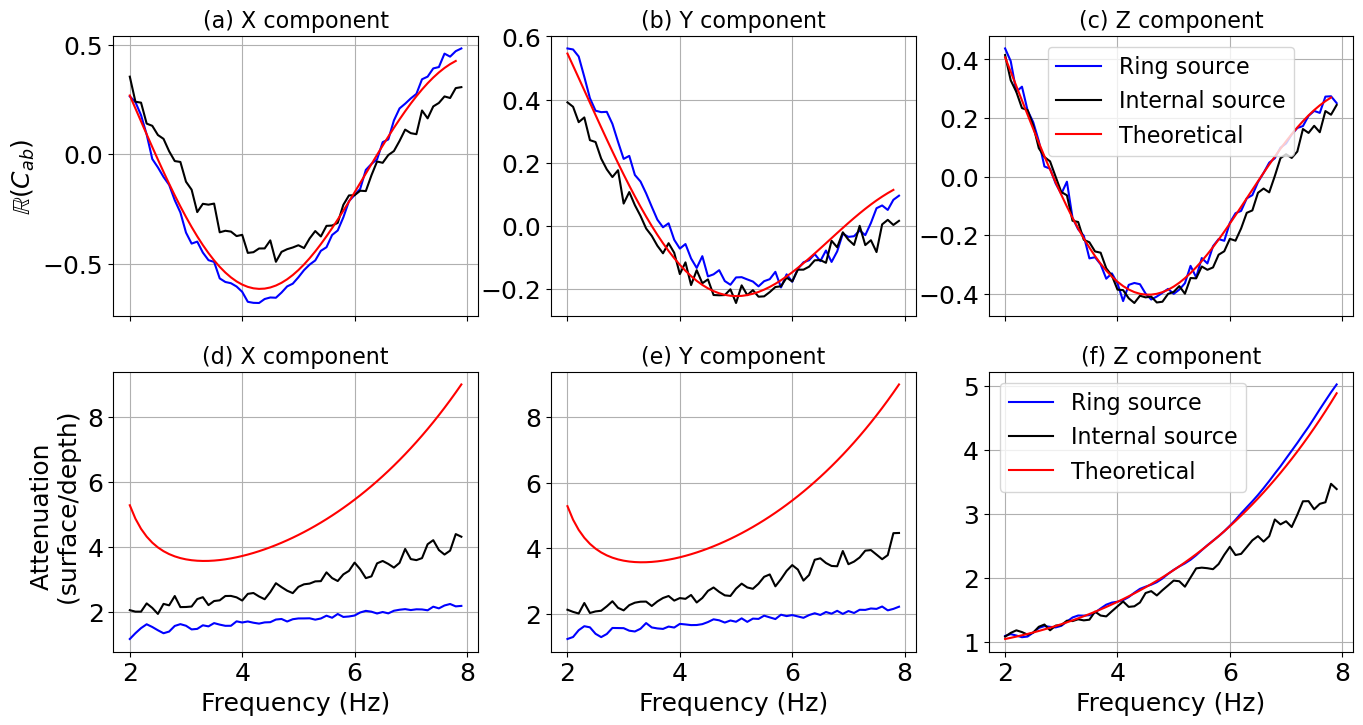

In [33]:
# script for plotting the simulated and theoretical cross-correlations and attenuatiuon
# for a homogeneous halfspace model
import numpy as np
import os
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy.io import savemat
from scipy.special import j0
from scipy.special import spherical_jn
from scipy.special import jv
import scipy.constants as const

from modules import plotUtils

# state the filepaths
ccBigRingPath = '/home/koley/Results/TutorialOut/HomoBigRingFullCCOut/OutDispRea/BigRingCC.mat'
ccInternalPath = '/home/koley/Results/TutorialOut/HomoInternalFullCCOut/OutDispRea/InternalCC.mat'
attnBigRingPath = '/home/koley/Results/TutorialOut/HomoBigRingFullAttnOut/OutDispRea/BigRingAttn.mat'
attnInternalPath = '/home/koley/Results/TutorialOut/HomoInternalFullAttnOut/OutDispRea/InternalAttn.mat'

# use loadmat to load them
ccBR = loadmat(ccBigRingPath)
ccIn = loadmat(ccInternalPath)
attnBR = loadmat(attnBigRingPath)
attnIn = loadmat(attnInternalPath)

# load the plot style module
plotUtils.set_plot_style(labelsize=18, ticksize=18, legendsize=16)

# create the plot
fig,ax = plt.subplots(2,3,figsize = (16,8), sharex=True)
ax[0,0].plot(ccBR["freqOut"][0],ccBR["ccXBigRing"][0],'b',label='Ring source')
ax[0,1].plot(ccBR["freqOut"][0],ccBR["ccYBigRing"][0],'b',label='Ring source')
ax[0,2].plot(ccBR["freqOut"][0],ccBR["ccZBigRing"][0],'b', label='Ring source')

# for internal source distribution
ax[0,0].plot(ccIn["freqOut"][0],ccIn["ccXInternal"][0],'k',label='Internal source')
ax[0,1].plot(ccIn["freqOut"][0],ccIn["ccYInternal"][0],'k',label='Internal source')
ax[0,2].plot(ccIn["freqOut"][0],ccIn["ccZInternal"][0],'k',label='Internal source')

# plot the theoretical ones
ax[0,0].plot(ccIn["fTheo"][0],ccIn["ccTheoX"][0],'r',label='Theoretical')
ax[0,1].plot(ccIn["fTheo"][0],ccIn["ccTheoY"][0],'r',label='Theoretical')
ax[0,2].plot(ccIn["fTheo"][0],ccIn["ccTheoZ"][0],'r',label='Theoretical')
# set the labels and legends
ax[0,2].legend()
ax[0,0].set_ylabel(r"$\mathbb{R}(C_{ab})$")
ax[0,0].grid(); ax[0,0].set_title('(a) X component')
ax[0,1].grid(); ax[0,1].set_title('(b) Y component')
ax[0,2].grid(); ax[0,2].set_title('(c) Z component')

# plot the attenuations
ax[1,0].plot(attnBR["freqOut"][0],attnBR["attnSimBigRing"][:,0],'b',label='Ring source')
ax[1,1].plot(attnBR["freqOut"][0],attnBR["attnSimBigRing"][:,1],'b',label='Ring source')
ax[1,2].plot(attnBR["freqOut"][0],attnBR["attnSimBigRing"][:,2],'b', label='Ring source')

# internal sources
ax[1,0].plot(attnIn["freqOut"][0],attnIn["attnSimInternal"][:,0],'k',label='Internal source')
ax[1,1].plot(attnIn["freqOut"][0],attnIn["attnSimInternal"][:,1],'k',label='Internal source')
ax[1,2].plot(attnIn["freqOut"][0],attnIn["attnSimInternal"][:,2],'k', label='Internal source')

# plot the theoretical ones
ax[1,0].plot(attnIn["freqOut"][0],1/attnIn["Th"][0],'r',label='Theoretical')
ax[1,1].plot(attnIn["freqOut"][0],1/attnIn["Th"][0],'r',label='Theoretical')
ax[1,2].plot(attnIn["freqOut"][0],1/attnIn["Tz"][0],'r',label='Theoretical')
# set the labels and legends
ax[1,2].legend()
ax[1,0].set_ylabel('Attenuation \n (surface/depth)')
ax[1,0].grid(); ax[1,0].set_title('(d) X component'); ax[1,0].set_xlabel('Frequency (Hz)')
ax[1,1].grid(); ax[1,1].set_title('(e) Y component'); ax[1,1].set_xlabel('Frequency (Hz)')
ax[1,2].grid(); ax[1,2].set_title('(f) Z component'); ax[1,2].set_xlabel('Frequency (Hz)')

